In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
pd.set_option('display.max_columns', None)

# K-Means Steps
1. Choose the number K of clusters.
2. Select at random K points, the centroids, not necessarily from your data.
3. Assign each data point to the closest centroid.
4. Compute and place the new centroid of each cluster.
5. Reassign each data point to the new closest centroid. If any assignment took place, go to step 4; otherwise, finish.

In [2]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

X, Y = make_blobs(n_samples=200, n_features=2, centers=3, 
        cluster_std=1, shuffle=True, random_state=7)

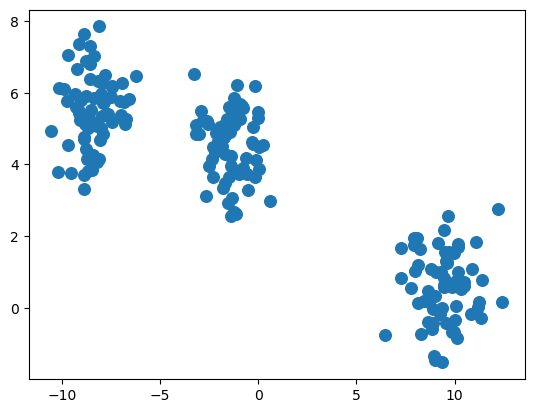

In [3]:
plt.scatter(X[:, 0], X[:, 1], marker='o', s=70)
plt.show()

## K-Means Fit

In [4]:
from sklearn.cluster import KMeans

km = KMeans(n_clusters=3, max_iter=500)
y_km = km.fit_predict(X)

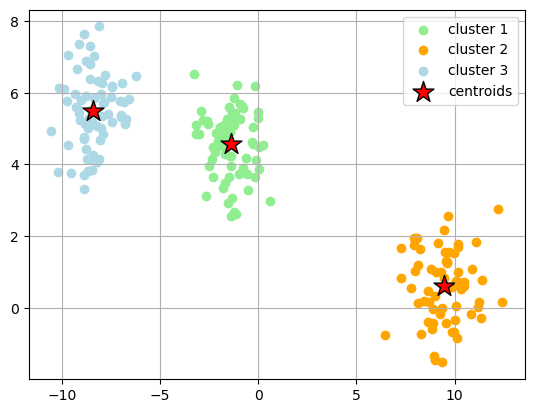

In [5]:
# plot the 3 clusters
plt.scatter(X[y_km == 0, 0], X[y_km == 0, 1], c='lightgreen', label='cluster 1')
plt.scatter(X[y_km == 1, 0], X[y_km == 1, 1], c='orange',  label='cluster 2')
plt.scatter(X[y_km == 2, 0], X[y_km == 2, 1], c='lightblue',  label='cluster 3')

# plot the centroids
plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
            s=250, marker='*',c='red', edgecolor='black',label='centroids')
plt.legend(scatterpoints=1)
plt.grid()

## Optimal Number of Clusters

### Elbow Method

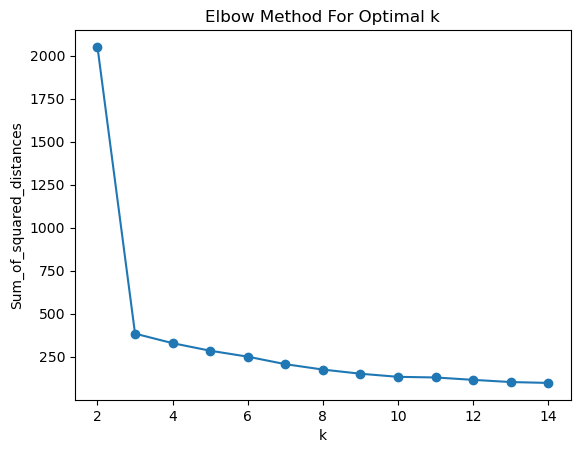

In [6]:
Sum_of_squared_distances = []
K = range(2,15)
for k in K:
    km = KMeans(n_clusters=k, init='random', n_init=10, max_iter=500,  tol=1e-04, random_state=0)
    km = km.fit(X)
    
    Sum_of_squared_distances.append(km.inertia_)

# Plot Results
plt.plot(K, Sum_of_squared_distances, marker='o')
plt.xlabel('k')
plt.ylabel('Sum_of_squared_distances')
plt.title('Elbow Method For Optimal k')
plt.show()

### Silhouette Analysis

In [7]:
from sklearn.metrics import silhouette_score
for n_clusters in range(2,10):
    clusterer = KMeans(n_clusters=n_clusters, random_state=10)
    cluster_labels = clusterer.fit_predict(X)
    silhouette_avg = silhouette_score(X, cluster_labels)
    print("For n_clusters =", n_clusters,
          "The average silhouette_score is: {:4f}".format(silhouette_avg))

For n_clusters = 2 The average silhouette_score is: 0.748643
For n_clusters = 3 The average silhouette_score is: 0.785358
For n_clusters = 4 The average silhouette_score is: 0.641820
For n_clusters = 5 The average silhouette_score is: 0.461010
For n_clusters = 6 The average silhouette_score is: 0.477107
For n_clusters = 7 The average silhouette_score is: 0.325233
For n_clusters = 8 The average silhouette_score is: 0.478205
For n_clusters = 9 The average silhouette_score is: 0.361148


# Case Study

In [8]:
df = pd.read_csv('https://raw.githubusercontent.com/hovhannisyan91/data_analytics_with_python/refs/heads/main/data/clustering/travel.csv',
parse_dates = ['date_time','srch_ci','srch_co'])
df.head()

,date_time,site_name,posa_continent,user_location_country,user_location_region,user_location_city,orig_destination_distance,user_id,is_mobile,is_package,channel,srch_ci,srch_co,srch_adults_cnt,srch_children_cnt,srch_rm_cnt,srch_destination_id,srch_destination_type_id,is_booking,cnt,hotel_continent,hotel_country,hotel_market,hotel_cluster
0,2014-11-03 16:02:00,24,2,77,871,36643,456.1151,792280,0,1,1,2014-12-15,2014-12-19,2,0,1,8286,1,0,1,0,63,1258,68
1,2013-03-13 19:25:00,11,3,205,135,38749,232.4737,961995,0,0,9,2013-03-13,2013-03-14,2,0,1,1842,3,0,1,2,198,786,37
2,2014-10-13 13:20:00,2,3,66,314,48562,4468.2720,495669,0,1,9,2015-04-03,2015-04-10,2,0,1,8746,1,0,1,6,105,29,22
3,2013-11-05 10:40:00,11,3,205,411,52752,171.6021,106611,0,0,0,2013-11-07,2013-11-08,2,0,1,6210,3,1,1,2,198,1234,42
4,2014-06-10 13:34:00,2,3,66,174,50644,NaN,596177,0,0,9,2014-08-03,2014-08-08,2,1,1,12812,5,0,1,2,50,368,83


In [9]:
df.to_csv('../data/travel.csv')

In [10]:
# Get some base information on our dataset
print ("Rows:   " , df.shape[0])
print ("Columns: " , df.shape[1])
df.info()

Rows:    100000
Columns:  24
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 24 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   date_time                  100000 non-null  datetime64[us]
 1   site_name                  100000 non-null  int64         
 2   posa_continent             100000 non-null  int64         
 3   user_location_country      100000 non-null  int64         
 4   user_location_region       100000 non-null  int64         
 5   user_location_city         100000 non-null  int64         
 6   orig_destination_distance  63915 non-null   float64       
 7   user_id                    100000 non-null  int64         
 8   is_mobile                  100000 non-null  int64         
 9   is_package                 100000 non-null  int64         
 10  channel                    100000 non-null  int64         
 11  srch_ci                    99878 no

In [11]:
# Get statistics for our Numerical Columns
df.isnull().sum()

date_time                        0
site_name                        0
posa_continent                   0
user_location_country            0
user_location_region             0
user_location_city               0
orig_destination_distance    36085
user_id                          0
is_mobile                        0
is_package                       0
channel                          0
srch_ci                        122
srch_co                        122
srch_adults_cnt                  0
srch_children_cnt                0
srch_rm_cnt                      0
srch_destination_id              0
srch_destination_type_id         0
is_booking                       0
cnt                              0
hotel_continent                  0
hotel_country                    0
hotel_market                     0
hotel_cluster                    0
dtype: int64

## Correlation Matrix

In [12]:
# Create our Corelation Matrix
corr = df.corr()
corr

,date_time,site_name,posa_continent,user_location_country,user_location_region,user_location_city,orig_destination_distance,user_id,is_mobile,is_package,channel,srch_ci,srch_co,srch_adults_cnt,srch_children_cnt,srch_rm_cnt,srch_destination_id,srch_destination_type_id,is_booking,cnt,hotel_continent,hotel_country,hotel_market,hotel_cluster
date_time,1.000000,-0.024018,-0.010503,-0.021281,-0.012536,-0.004335,-0.002967,-0.017718,0.023642,-0.001773,-0.059976,0.952221,0.951117,0.013011,-0.075139,-0.004368,0.011650,-0.040562,-0.032699,-0.089140,-0.008460,-0.005722,0.003028,-0.000059
site_name,-0.024018,1.000000,-0.637743,0.159283,0.130818,-0.013471,0.027609,0.030404,-0.005418,0.048820,-0.027780,-0.001569,-0.001054,-0.013405,-0.031962,0.016585,0.034895,-0.006934,-0.013460,0.022274,0.201760,0.263167,-0.068316,-0.026689
posa_continent,-0.010503,-0.637743,1.000000,0.179726,-0.034647,0.039227,0.049808,-0.015209,0.016331,-0.093459,0.089680,-0.026851,-0.027669,0.012350,0.034453,-0.033712,-0.015535,0.037172,0.013319,-0.018952,-0.333578,-0.156578,0.049214,0.018297
user_location_country,-0.021281,0.159283,0.179726,1.000000,0.058496,0.122686,0.047689,-0.021091,0.003728,-0.025284,0.109999,-0.020851,-0.020539,0.042526,0.037101,0.000858,0.013486,0.028888,0.001284,0.003539,-0.063744,0.097624,0.015569,-0.011876
user_location_region,-0.012536,0.130818,-0.034647,0.058496,1.000000,0.132457,0.136560,0.002225,0.016982,0.040482,-0.001600,0.009723,0.010378,0.005487,0.014009,0.000254,0.022567,0.001376,0.000253,-0.007570,0.043027,-0.050301,0.040367,0.004984
user_location_city,-0.004335,-0.013471,0.039227,0.122686,0.132457,1.000000,0.014178,-0.007989,-0.003741,0.013032,0.023497,-0.004184,-0.003894,0.006628,0.002638,-0.000694,0.000786,-0.004399,-0.002655,-0.002175,0.007759,-0.001987,0.008558,0.000102
orig_destination_distance,-0.002967,0.027609,0.049808,0.047689,0.136560,0.014178,1.000000,0.017015,-0.059464,0.041991,-0.000398,0.080935,0.083821,-0.024039,-0.059722,-0.012484,-0.036314,-0.042859,-0.033480,0.009483,0.416180,0.254321,-0.090112,0.003624
user_id,-0.017718,0.030404,-0.015209,-0.021091,0.002225,-0.007989,0.017015,1.000000,-0.011439,-0.018901,-0.003593,-0.014944,-0.014900,-0.007370,0.002983,-0.001625,0.002716,0.007133,0.001561,0.001355,0.002447,0.008707,-0.002463,0.003202
is_mobile,0.023642,-0.005418,0.016331,0.003728,0.016982,-0.003741,-0.059464,-0.011439,1.000000,0.046903,-0.030770,0.024625,0.024727,0.016661,0.018211,-0.022565,-0.007140,-0.016039,-0.028623,0.008084,-0.024144,-0.029574,0.007644,0.012145
is_package,-0.001773,0.048820,-0.093459,-0.025284,0.040482,0.013032,0.041991,-0.018901,0.046903,1.000000,-0.011269,0.057690,0.061811,-0.024097,-0.037673,-0.036653,-0.146647,-0.224422,-0.081307,0.126500,0.108993,-0.044426,-0.014636,0.031399


Text(0.5, 1.0, 'Heatmap of Correlation Matrix')

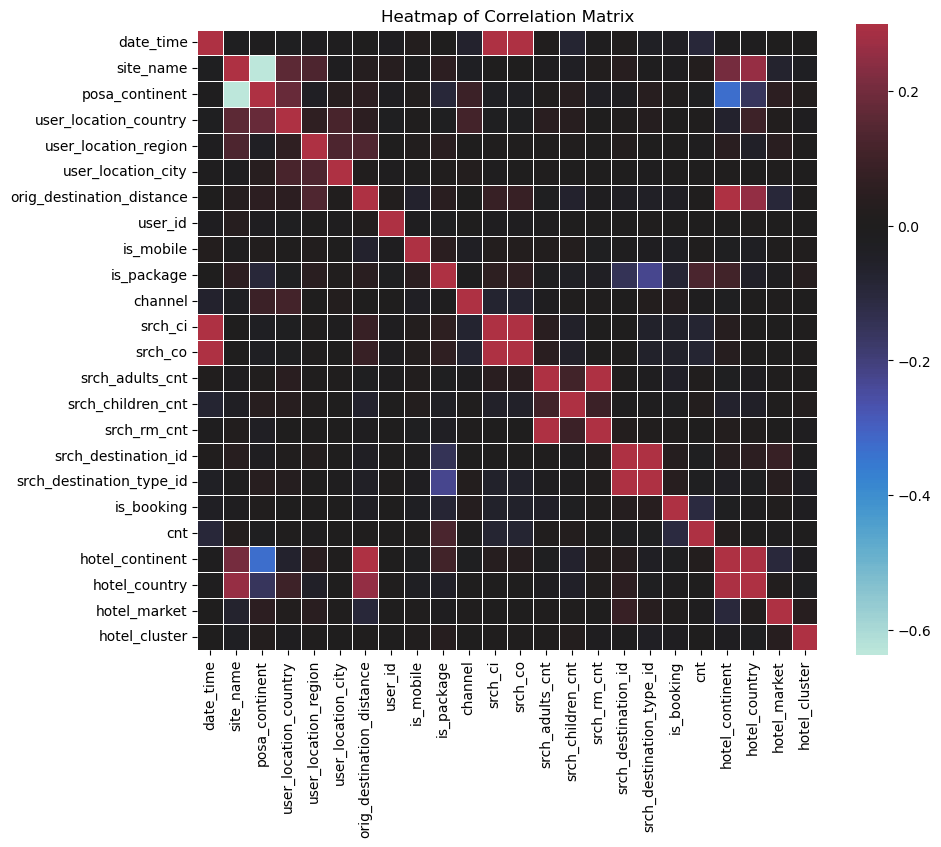

In [13]:
plt.figure(figsize = (10,10))

sns.heatmap(corr,xticklabels=corr.columns.values,
           yticklabels=corr.columns.values,vmax=.3, center=0, square=True, linewidths=.5, cbar_kws={"shrink": .82})
plt.title('Heatmap of Correlation Matrix')

## Distributions

array([[<Axes: title={'center': 'channel'}>,
        <Axes: title={'center': 'is_booking'}>,
        <Axes: title={'center': 'is_mobile'}>],
       [<Axes: title={'center': 'orig_destination_distance'}>,
        <Axes: title={'center': 'srch_rm_cnt'}>,
        <Axes: title={'center': 'srch_adults_cnt'}>],
       [<Axes: title={'center': 'srch_children_cnt'}>, <Axes: >,
        <Axes: >]], dtype=object)

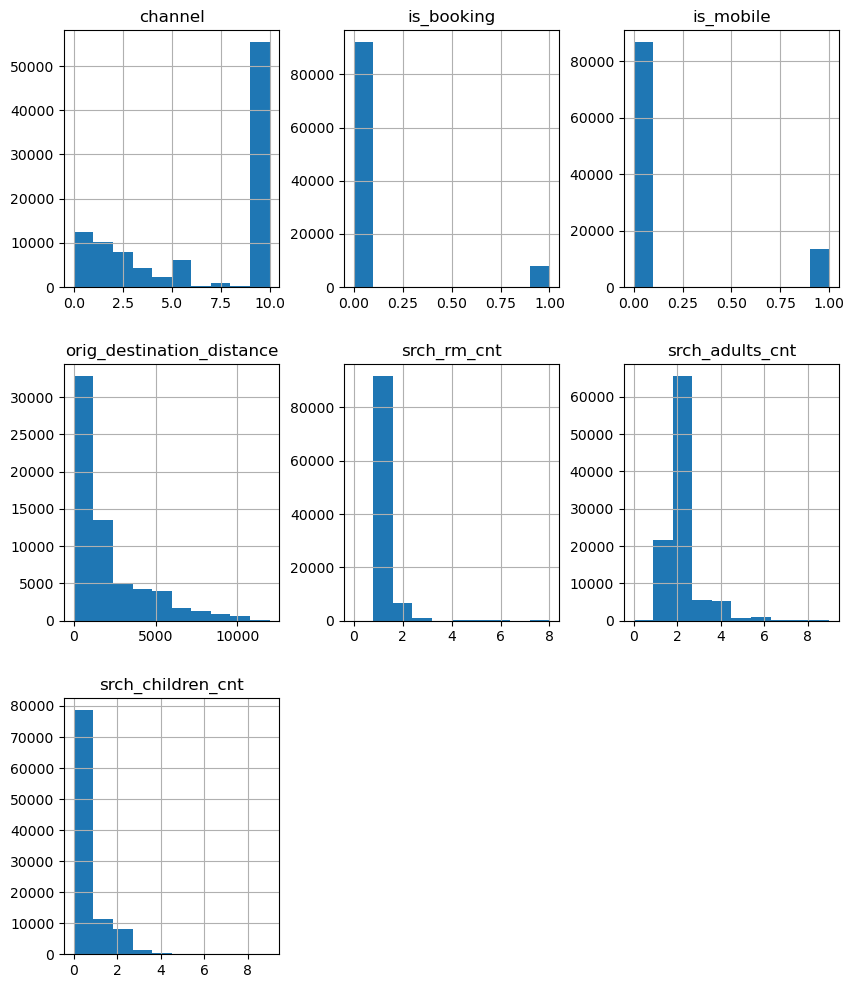

In [14]:
df[['channel', 'is_booking', 'is_mobile', 'orig_destination_distance',
        'srch_rm_cnt', 'srch_adults_cnt', 'srch_children_cnt']].hist(figsize=(10,12))

### `is_booking`

In [ ]:
# To view the bookings made per user
booking_count_per_user=df.groupby('user_id')['is_booking'].agg(num_of_bookings='count').reset_index()
booking_count_per_user.groupby('num_of_bookings')['user_id'].agg('count')

num_of_bookings
1    79189
2     8423
3     1065
4      161
5       24
6        1
Name: user_id, dtype: int64

In [17]:
# Merge with original data
df = df.merge(df.groupby('user_id')['is_booking'].agg(['count']).reset_index())
df.head()

,date_time,site_name,posa_continent,user_location_country,user_location_region,user_location_city,orig_destination_distance,user_id,is_mobile,is_package,channel,srch_ci,srch_co,srch_adults_cnt,srch_children_cnt,srch_rm_cnt,srch_destination_id,srch_destination_type_id,is_booking,cnt,hotel_continent,hotel_country,hotel_market,hotel_cluster,count
0,2014-11-03 16:02:00,24,2,77,871,36643,456.1151,792280,0,1,1,2014-12-15,2014-12-19,2,0,1,8286,1,0,1,0,63,1258,68,2
1,2013-03-13 19:25:00,11,3,205,135,38749,232.4737,961995,0,0,9,2013-03-13,2013-03-14,2,0,1,1842,3,0,1,2,198,786,37,1
2,2014-10-13 13:20:00,2,3,66,314,48562,4468.2720,495669,0,1,9,2015-04-03,2015-04-10,2,0,1,8746,1,0,1,6,105,29,22,1
3,2013-11-05 10:40:00,11,3,205,411,52752,171.6021,106611,0,0,0,2013-11-07,2013-11-08,2,0,1,6210,3,1,1,2,198,1234,42,2
4,2014-06-10 13:34:00,2,3,66,174,50644,NaN,596177,0,0,9,2014-08-03,2014-08-08,2,1,1,12812,5,0,1,2,50,368,83,1


## Logical Check

### Available Travelers

In [18]:
pd.crosstab(df['srch_adults_cnt'], df['srch_children_cnt'])

srch_children_cnt,0,1,2,3,4,5,6,7,8,9
srch_adults_cnt,,,,,,,,,,
0,174,2,3,2,0,0,0,0,0,0
1,18749,2137,523,117,11,1,9,1,2,0
2,50736,7093,6529,972,208,14,7,1,0,0
3,3645,1131,469,131,27,5,2,2,0,2
4,3933,690,494,77,83,9,4,0,0,0
5,535,131,41,20,6,4,2,0,0,0
6,669,73,53,28,18,13,7,0,0,0
7,99,20,5,8,6,3,0,0,0,0
8,183,12,13,2,6,1,3,2,2,1


In [19]:
df[(df['srch_adults_cnt']==0) & (df['srch_children_cnt']==0)].head()

,date_time,site_name,posa_continent,user_location_country,user_location_region,user_location_city,orig_destination_distance,user_id,is_mobile,is_package,channel,srch_ci,srch_co,srch_adults_cnt,srch_children_cnt,srch_rm_cnt,srch_destination_id,srch_destination_type_id,is_booking,cnt,hotel_continent,hotel_country,hotel_market,hotel_cluster,count
115,2014-10-07 14:43:00,2,3,66,293,52284,NaN,909952,0,1,9,2015-01-10,2015-01-15,0,0,1,8250,1,0,1,2,50,628,1,1
496,2013-06-15 19:12:00,29,1,52,40,29080,NaN,150434,0,1,9,2013-09-16,2013-09-20,0,0,2,25408,6,0,2,6,15,1534,46,1
1261,2014-10-26 10:20:00,2,3,66,220,22648,5148.4830,588617,1,1,2,2015-08-24,2015-09-03,0,0,1,8746,1,0,1,6,105,29,78,1
1428,2014-11-16 10:21:00,2,3,66,174,53801,1638.7472,207522,1,1,0,2015-04-18,2015-04-25,0,0,1,8810,1,0,1,4,8,1532,52,1
1539,2014-12-28 19:16:00,2,3,66,363,31138,1526.8518,938404,0,1,0,NaT,NaT,0,0,1,8277,1,0,1,2,50,412,9,1


In [20]:
df[(df['srch_adults_cnt']==0) & (df['srch_children_cnt']==0)].shape

(174, 25)

In [21]:
df.drop(df[df['srch_adults_cnt'] + df['srch_children_cnt']==0].index, inplace=True)

### Dates

In [23]:
# The chronology: Booking -> Check-In -> Check-out

# Check-out date need to be later than check-in date
# Check-in date need to be later than booking date
# Change the timestamp of ‘date_time’ (2014-11-03 16:02:28) to simply "2014-11-03"

df['date'] = pd.to_datetime(df['date_time'].apply(lambda x: x.date()))

df.head()

,date_time,site_name,posa_continent,user_location_country,user_location_region,user_location_city,orig_destination_distance,user_id,is_mobile,is_package,channel,srch_ci,srch_co,srch_adults_cnt,srch_children_cnt,srch_rm_cnt,srch_destination_id,srch_destination_type_id,is_booking,cnt,hotel_continent,hotel_country,hotel_market,hotel_cluster,count,date
0,2014-11-03 16:02:00,24,2,77,871,36643,456.1151,792280,0,1,1,2014-12-15,2014-12-19,2,0,1,8286,1,0,1,0,63,1258,68,2,2014-11-03
1,2013-03-13 19:25:00,11,3,205,135,38749,232.4737,961995,0,0,9,2013-03-13,2013-03-14,2,0,1,1842,3,0,1,2,198,786,37,1,2013-03-13
2,2014-10-13 13:20:00,2,3,66,314,48562,4468.2720,495669,0,1,9,2015-04-03,2015-04-10,2,0,1,8746,1,0,1,6,105,29,22,1,2014-10-13
3,2013-11-05 10:40:00,11,3,205,411,52752,171.6021,106611,0,0,0,2013-11-07,2013-11-08,2,0,1,6210,3,1,1,2,198,1234,42,2,2013-11-05
4,2014-06-10 13:34:00,2,3,66,174,50644,NaN,596177,0,0,9,2014-08-03,2014-08-08,2,1,1,12812,5,0,1,2,50,368,83,1,2014-06-10


In [24]:
df[df['srch_co'] < df['srch_ci']][['srch_co', 'srch_ci']].shape

(2, 2)

In [25]:
df[df['srch_ci'] < df['date']][['srch_ci', 'date']].shape

(25, 2)

## Feature Enrichment

In [26]:
def duration(row, start, end):
    delta=(row[end]-row[start])/np.timedelta64(1,'D')
    if delta<=0:
        return np.nan
    else:
        return delta

In [27]:
df['duration'] = df.apply(duration, args=('srch_ci','srch_co'),axis=1)

In [28]:
df['days_in_advance'] = df.apply(duration,args=('date','srch_ci'), axis=1)

## Statistical Analysis of Booking Channels

In [29]:
(df
    .groupby('channel')['is_booking']
    .agg(booking_rate= 'mean', num_of_bookings= 'count')
    .reset_index()
    .sort_values(by='channel'))

,channel,booking_rate,num_of_bookings
0,0,0.072184,12482
1,1,0.069568,10249
2,2,0.060583,7824
3,3,0.060482,4398
4,4,0.120438,2192
5,5,0.094533,6146
6,6,0.068323,161
7,7,0.043263,809
8,8,0.051852,270
9,9,0.085365,55280


## Clustering

In [31]:
# Our selected features
features_to_explore = ['duration', 'days_in_advance', 'orig_destination_distance', 'is_mobile',
            'is_package', 'srch_adults_cnt', 'srch_children_cnt', 'srch_rm_cnt']


df_clustering = df[features_to_explore + ['user_location_city']]

df_clustering_groups = (df_clustering
                            .groupby('user_location_city')
                            .mean()
                            .reset_index()
                            .dropna(axis=0))

## Standardize our Data

In [32]:
from sklearn import preprocessing
df_clustering_std = df_clustering_groups.copy()

df_clustering_std[features_to_explore] = preprocessing.scale(df_clustering_std[features_to_explore])

df_clustering_std.head()

,user_location_city,duration,days_in_advance,orig_destination_distance,is_mobile,is_package,srch_adults_cnt,srch_children_cnt,srch_rm_cnt
0,0,-0.685258,0.447140,0.314747,-0.619979,-0.023150,-0.511139,-0.704997,-0.331661
2,3,0.564013,0.651185,1.020233,-0.347544,0.125553,-0.207376,0.201429,-0.331661
3,7,5.164984,-0.007237,2.600430,-0.619979,2.504801,-0.113910,-0.704997,-0.331661
5,14,1.752343,-0.500401,2.195332,-0.619979,-0.865800,-0.113910,0.739619,-0.331661
8,21,0.777303,-0.594601,0.221515,-0.619979,0.819500,-0.908368,1.221158,-0.331661


## K-means Clustering

In [33]:
km = KMeans(n_clusters=3, max_iter=300, random_state=123)
df_clustering_std['cluster'] = km.fit_predict(df_clustering_std[features_to_explore])

df_clustering_std.head()

,user_location_city,duration,days_in_advance,orig_destination_distance,is_mobile,is_package,srch_adults_cnt,srch_children_cnt,srch_rm_cnt,cluster
0,0,-0.685258,0.447140,0.314747,-0.619979,-0.023150,-0.511139,-0.704997,-0.331661,2
2,3,0.564013,0.651185,1.020233,-0.347544,0.125553,-0.207376,0.201429,-0.331661,1
3,7,5.164984,-0.007237,2.600430,-0.619979,2.504801,-0.113910,-0.704997,-0.331661,0
5,14,1.752343,-0.500401,2.195332,-0.619979,-0.865800,-0.113910,0.739619,-0.331661,1
8,21,0.777303,-0.594601,0.221515,-0.619979,0.819500,-0.908368,1.221158,-0.331661,0


## Principal Component Analysis (PCA)

In [34]:
from sklearn import decomposition

pca = decomposition.PCA(n_components=2, whiten=True)

pca_results = pca.fit_transform(df_clustering_std[features_to_explore])

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)


print(f"Comulative Variance:  {cumulative_variance}")
explained_variance

Comulative Variance:  [0.21982537 0.40991447]


array([0.21982537, 0.1900891 ])

##### 40% of the variance is explaned by two columns!

In [35]:
df_clustering_std['x'] = pca_results[:,0]
df_clustering_std['y'] = pca_results[:,1]

df_clustering_std.head()

,user_location_city,duration,days_in_advance,orig_destination_distance,is_mobile,is_package,srch_adults_cnt,srch_children_cnt,srch_rm_cnt,cluster,x,y
0,0,-0.685258,0.447140,0.314747,-0.619979,-0.023150,-0.511139,-0.704997,-0.331661,2,0.095833,-0.521284
2,3,0.564013,0.651185,1.020233,-0.347544,0.125553,-0.207376,0.201429,-0.331661,1,0.929255,-0.156800
3,7,5.164984,-0.007237,2.600430,-0.619979,2.504801,-0.113910,-0.704997,-0.331661,0,3.937174,-0.238704
5,14,1.752343,-0.500401,2.195332,-0.619979,-0.865800,-0.113910,0.739619,-0.331661,1,1.051649,-0.087671
8,21,0.777303,-0.594601,0.221515,-0.619979,0.819500,-0.908368,1.221158,-0.331661,0,0.425947,-0.558020


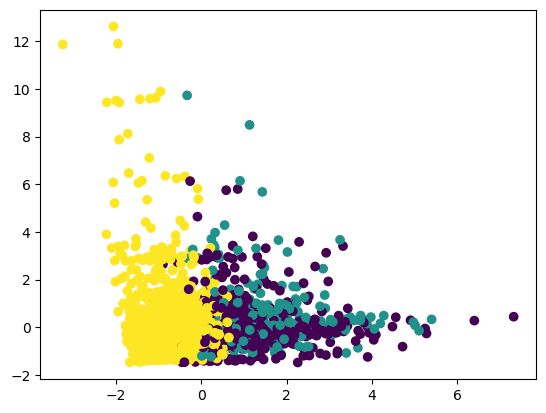

In [36]:
plt.scatter(df_clustering_std['x'], df_clustering_std['y'], c=df_clustering_std['cluster'])
plt.show()

## with 2 clusters

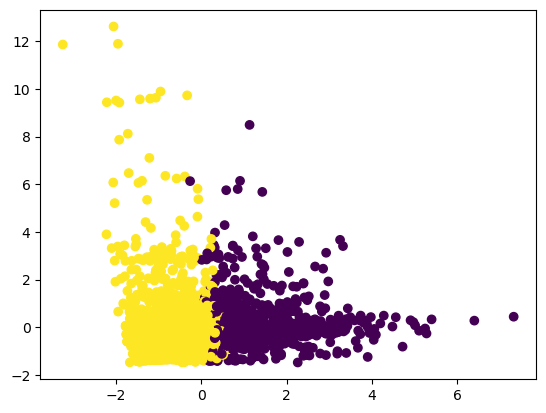

In [37]:
km = KMeans(n_clusters=2, max_iter=300, random_state=None)
df_clustering_std['cluster'] = km.fit_predict(df_clustering_std[features_to_explore])

pca = decomposition.PCA(n_components=2, whiten=True)
pca_results = pca.fit_transform(df_clustering_std[features_to_explore])

df_clustering_std['x'] = pca_results[:,0]
df_clustering_std['y'] = pca_results[:,1]

plt.scatter(df_clustering_std['x'], df_clustering_std['y'], c=df_clustering_std['cluster'])
plt.show()

## with 4 clusters

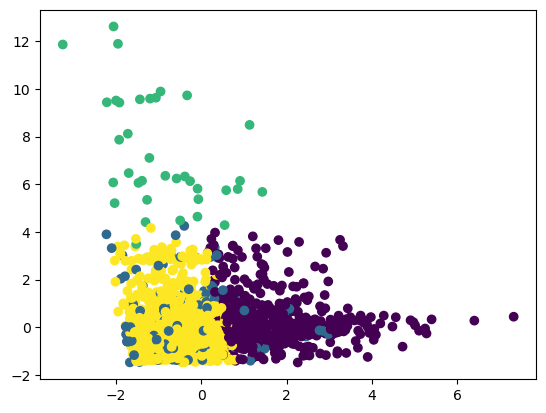

In [38]:
km = KMeans(n_clusters=4, max_iter=300, random_state=None)
df_clustering_std['cluster'] = km.fit_predict(df_clustering_std[features_to_explore])

pca = decomposition.PCA(n_components=2, whiten=True)
pca_results = pca.fit_transform(df_clustering_std[features_to_explore])

df_clustering_std['x'] = pca_results[:,0]
df_clustering_std['y'] = pca_results[:,1]

plt.scatter(df_clustering_std['x'], df_clustering_std['y'], c=df_clustering_std['cluster'])
plt.show()